# Map Generation Research — Multi-Floor Maze

Nghiên cứu và so sánh các thuật toán sinh map cho environment multi-floor maze.

## Mục tiêu
Tìm thuật sinh map **ổn định** cho 1 level phức tạp gồm:
- Start, Goal (có thể khác tầng)
- Bẫy (traps), Cửa (doors), Chìa khóa (keys)
- 3 loại quái: Patrol, Chaser, Sniper
- Đạn (ammo), HP packs
- Cầu thang lên/xuống (multi-floor)

## Thuật toán thử nghiệm
| # | Thuật | Ý tưởng chính |
|---|-------|---------------|
| A | **BSP Hiện tại** (Baseline) | Room BSP + corridor + lock fallback random |
| B | **BSP + Fixed Locks** | Cải thiện: 1 door tile/lock, chỉ chọn chokepoint |
| C | **Graph-First + Lock Tree** | Sinh room graph trước, tạo lock dependency, render grid |
| D | **Cellular Automata** | Sinh hang động hữu cơ, detect region, place items |

## Tiêu chí đánh giá
1. **Solvability**: 100% maps phải reachable
2. **Door correctness**: door tiles == key tiles
3. **Layout quality**: open area, path length đa dạng
4. **Stability**: kết quả ổn định qua nhiều seeds


In [7]:
import sys, io, base64
from collections import deque, defaultdict
from pathlib import Path

import numpy as np
from IPython.display import display, HTML
from PIL import Image, ImageDraw, ImageFont

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mfm.env import CURRICULUM, MazeEnv, Tile, ProceduralMapGenerator

TARGET_CFG = {
    "name": "TestMaster",
    "width": 13, "height": 13, "n_floors": 3, "max_steps": 500,
    "agent_hp": 10, "agent_ammo": 8, "agent_max_ammo": 8, "agent_stamina": 6,
    "n_traps": 3, "n_health": 4, "n_ammo": 4,
    "enemies": [
        {"type": "sniper", "floor": 0},
        {"type": "chaser", "floor": 1},
        {"type": "patrol", "floor": 2},
        {"type": "chaser", "floor": 2},
    ],
    "locks": [{"k": 0, "d": 0}, {"k": 1, "d": 1}, {"k": 2, "d": 2}],
    "start_floor": 2, "goal_floor": 0,
}

N_SAMPLES = 30
SEEDS = list(range(42, 42 + N_SAMPLES))

print(f"Target: {TARGET_CFG['width']}x{TARGET_CFG['height']}, "
      f"{TARGET_CFG['n_floors']}F, "
      f"{len(TARGET_CFG['enemies'])} enemies, "
      f"{len(TARGET_CFG['locks'])} locks")


Target: 13x13, 3F, 4 enemies, 3 locks


In [8]:
CELL_PX, GAP_PX, INFO_H = 44, 12, 60

TILE_COLOR = {
    Tile.FLOOR: (250,250,250), Tile.WALL: (40,40,40),
    Tile.STAIR_UP: (180,180,255), Tile.STAIR_DOWN: (150,150,220),
    Tile.GOAL: (255,255,100), Tile.TRAP: (255,80,80),
    Tile.START: (180,255,180), Tile.DOOR: (180,140,100),
    Tile.KEY: (220,180,80), Tile.HEALTH_PACK: (255,200,200),
    Tile.AMMO_PACK: (240,240,150),
}
TILE_LABEL = {
    Tile.STAIR_UP:"SU", Tile.STAIR_DOWN:"SD", Tile.GOAL:"G",
    Tile.TRAP:"X", Tile.START:"S", Tile.DOOR:"D", Tile.KEY:"K",
    Tile.HEALTH_PACK:"+", Tile.AMMO_PACK:"A",
}
ENEMY_STYLE = {
    "patrol": ((200,100,200),"P"),
    "chaser": ((255,50,50),"E"),
    "sniper": ((255,165,0),"S"),
}

def _font(size):
    for p in ["/System/Library/Fonts/Supplemental/Arial Bold.ttf",
              "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
              "Arial.ttf"]:
        try: return ImageFont.truetype(p, size)
        except: continue
    return ImageFont.load_default()

FT = _font(int(CELL_PX * 0.55))
FU = _font(int(CELL_PX * 0.42))
FI = _font(14)
FTT = _font(16)

def show_img(pil_img, max_width=900):
    w, h = pil_img.size
    if w > max_width:
        r = max_width / w
        pil_img = pil_img.resize((int(w*r), int(h*r)), Image.LANCZOS)
    buf = io.BytesIO(); pil_img.save(buf, format="PNG")
    display(HTML(f'<img src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}">'))

def render_floors(floors, enemies, agent_pos, goal, title=""):
    nf = len(floors); h, w = floors[0].shape
    mw, mh = w*CELL_PX, h*CELL_PX
    tw = nf*mw + (nf-1)*GAP_PX + 16
    th = mh + INFO_H + 30
    img = Image.new("RGB", (tw, th), (245,245,245))
    d = ImageDraw.Draw(img)
    d.rectangle([0,0,tw,24], fill=(30,30,45))
    d.text((8,4), title, fill=(255,255,255), font=FTT)
    for fi in range(nf):
        grid = floors[fi]; ox = 8+fi*(mw+GAP_PX); oy = 28
        d.text((ox+mw//2, oy-1), f"Floor {fi}", fill=(80,80,100), font=FI, anchor="mt")
        oy += 14
        for y in range(h):
            for x in range(w):
                t = int(grid[y][x])
                x1, y1 = ox+x*CELL_PX, oy+y*CELL_PX
                c = TILE_COLOR.get(t, (250,250,250))
                d.rectangle([x1,y1,x1+CELL_PX-2,y1+CELL_PX-2], fill=c, outline=(150,150,150))
                lb = TILE_LABEL.get(t)
                if lb: d.text((x1+CELL_PX//2, y1+CELL_PX//2), lb, fill=(0,0,0), font=FT, anchor="mm")
        for e in enemies:
            if e.get("floor") == fi:
                ec, lbl = ENEMY_STYLE.get(e["type"], ((150,150,150),"?"))
                ex, ey = e.get("x",0), e.get("y",0)
                d.ellipse([ox+ex*CELL_PX+4, oy+ey*CELL_PX+4,
                           ox+ex*CELL_PX+CELL_PX-4, oy+ey*CELL_PX+CELL_PX-4],
                          fill=ec, outline=(0,0,0), width=2)
                d.text((ox+ex*CELL_PX+CELL_PX//2, oy+ey*CELL_PX+CELL_PX//2),
                       lbl, fill=(255,255,255), font=FU, anchor="mm")
        ax, ay, af = agent_pos
        if af == fi:
            d.ellipse([ox+ax*CELL_PX+5, oy+ay*CELL_PX+5,
                       ox+ax*CELL_PX+CELL_PX-5, oy+ay*CELL_PX+CELL_PX-5],
                      fill=(100,150,255), outline=(0,0,0), width=2)
            d.text((ox+ax*CELL_PX+CELL_PX//2, oy+ay*CELL_PX+CELL_PX//2),
                   "@", fill=(0,0,0), font=FU, anchor="mm")
        gx, gy, gf = goal
        if gf == fi:
            d.rectangle([ox+gx*CELL_PX+3, oy+gy*CELL_PX+3,
                         ox+gx*CELL_PX+CELL_PX-3, oy+gy*CELL_PX+CELL_PX-3],
                        outline=(200,170,0), width=3)
    n_keys = sum(int(np.sum(f==int(Tile.KEY))) for f in floors)
    n_doors = sum(int(np.sum(f==int(Tile.DOOR))) for f in floors)
    n_traps = sum(int(np.sum(f==int(Tile.TRAP))) for f in floors)
    iy = mh + 48
    d.rectangle([0,iy-4,tw,th], fill=(35,35,50))
    dok = "✓" if n_doors==n_keys else f"✗ ({n_doors}D/{n_keys}K)"
    info = f"Traps:{n_traps}  |  Keys:{n_keys}  |  Doors:{n_doors}  |  DoorCheck:{dok}  |  Enemies:{len(enemies)}"
    d.text((8,iy+2), info, fill=(200,200,220), font=FI)
    return img

def quick_stats(floors, start, goal):
    n_keys = sum(int(np.sum(f==int(Tile.KEY))) for f in floors)
    n_doors = sum(int(np.sum(f==int(Tile.DOOR))) for f in floors)
    n_traps = sum(int(np.sum(f==int(Tile.TRAP))) for f in floors)
    total = sum(f.size for f in floors)
    fc = sum(int(np.sum(f!=int(Tile.WALL))) for f in floors)
    return {"n_keys":n_keys, "n_doors":n_doors, "n_traps":n_traps,
            "open_pct":round(fc/total*100,1), "door_ok":n_doors==n_keys}

print("Rendering utils ready.")


Rendering utils ready.


## A. Baseline — Thuật BSP hiện tại

Thuật hiện tại:
1. BSP split → rooms → corridors
2. `_perpendicular_seal` tạo seal 1-2 tiles → **1 lock = 1-2 DOOR tiles**
3. Mỗi DOOR tile tiêu 1 KEY → seal 2 tiles = cần 2 keys cho 1 lock logic
4. Khi `_place_lock` fail → fallback random → door vô nghĩa

Sinh 30 maps và đo lường.


In [9]:
print("=" * 70)
print("  Algorithm A: Baseline BSP")
print("=" * 70)

results_a = []
for seed in SEEDS:
    env = MazeEnv(TARGET_CFG, render_mode=None)
    env.reset(seed=seed)
    floors = env.floors
    sx, sy, sf = env.agent.x, env.agent.y, env.agent.floor
    gx, gy, gf = env.goal
    n_keys = sum(int(np.sum(f==int(Tile.KEY))) for f in floors)
    n_doors = sum(int(np.sum(f==int(Tile.DOOR))) for f in floors)
    n_traps = sum(int(np.sum(f==int(Tile.TRAP))) for f in floors)
    total = sum(f.size for f in floors)
    fc = sum(int(np.sum(f!=int(Tile.WALL))) for f in floors)
    gen = ProceduralMapGenerator(seed)
    dist = gen._bfs_multi(floors, (sx,sy,sf), (gx,gy,gf))
    results_a.append({"seed":seed, "path":dist, "open_pct":round(fc/total*100,1),
                       "n_keys":n_keys, "n_doors":n_doors, "n_traps":n_traps,
                       "door_ok":n_doors==n_keys, "reachable":dist>0})
    env.close()

n = len(results_a)
dok = sum(1 for r in results_a if r["door_ok"])
rch = sum(1 for r in results_a if r["reachable"])
paths = [r["path"] for r in results_a if r["path"]>0]
print(f"\n  Reachable:    {rch}/{n} ({rch/n*100:.0f}%)")
print(f"  Door correct: {dok}/{n} ({dok/n*100:.0f}%)")
print(f"  Path range:   {min(paths)}-{max(paths)} (mean={np.mean(paths):.1f})")
dm = [(r["seed"],r["n_doors"],r["n_keys"]) for r in results_a if not r["door_ok"]]
if dm:
    print(f"\n  ⚠ Door mismatch ({len(dm)} maps):")
    for s,nd,nk in dm[:5]: print(f"    seed={s}: {nd} door tiles, {nk} keys")


  Algorithm A: Baseline BSP

  Reachable:    30/30 (100%)
  Door correct: 25/30 (83%)
  Path range:   13-46 (mean=25.9)

  ⚠ Door mismatch (5 maps):
    seed=49: 4 door tiles, 3 keys
    seed=52: 4 door tiles, 3 keys
    seed=53: 4 door tiles, 3 keys
    seed=59: 4 door tiles, 3 keys
    seed=65: 4 door tiles, 3 keys



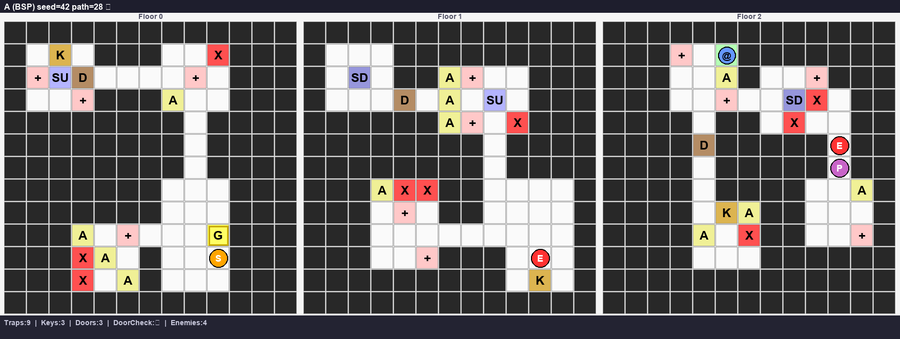


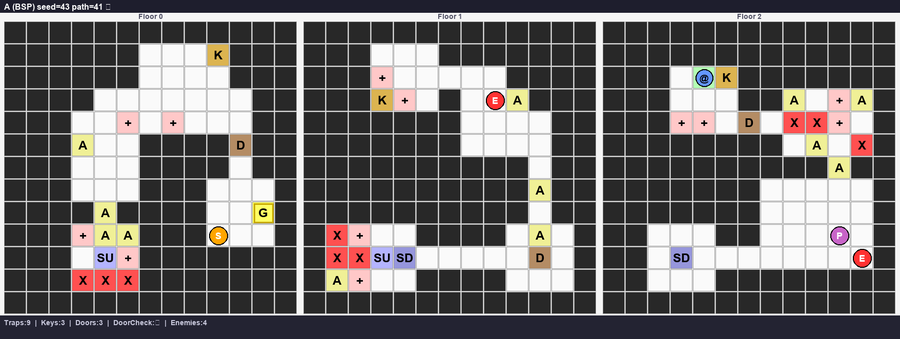


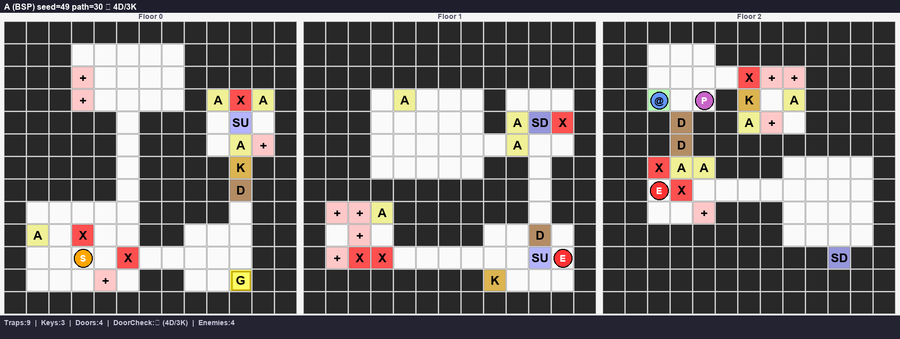


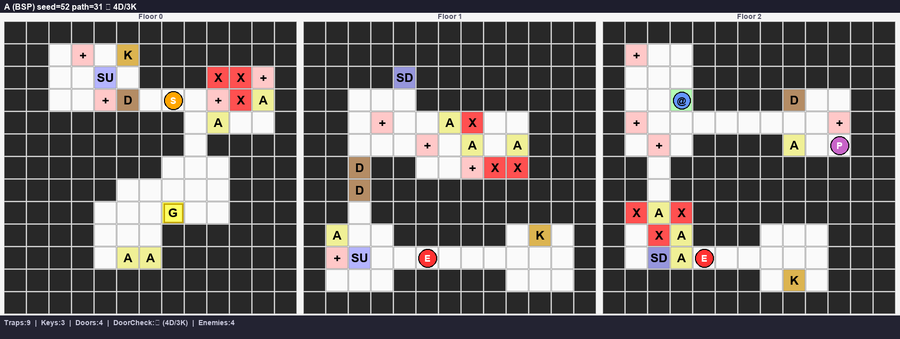

In [10]:
ok_s = [r["seed"] for r in results_a if r["door_ok"] and r["path"]>=25][:2]
bad_s = [r["seed"] for r in results_a if not r["door_ok"]][:2]
for seed in (ok_s + bad_s)[:4]:
    r = next(x for x in results_a if x["seed"]==seed)
    env = MazeEnv(TARGET_CFG, render_mode=None); env.reset(seed=seed)
    eds = [{"type":e.etype,"floor":e.floor,"x":e.x,"y":e.y} for e in env.enemies if e.alive]
    st = "✓" if r["door_ok"] else f"✗ {r['n_doors']}D/{r['n_keys']}K"
    img = render_floors(env.floors, eds, (env.agent.x,env.agent.y,env.agent.floor),
                         env.goal, f"A (BSP) seed={seed} path={r['path']} {st}")
    show_img(img); env.close()


## B. BSP + Fixed Lock System

Cải thiện:
1. **Single-tile door**: Chỉ dùng 1 DOOR tile cho 1 lock (tìm chokepoint thật)
2. **Validate**: Đảm bảo n_doors == n_keys sau generate
3. **Retry**: Nếu fail → retry seed khác


In [11]:
class FixedLockGenerator:
    def __init__(self, rng): self.rng = rng
    def _bsp_params(self, w, h):
        s = min(w,h)
        return (3,2) if s<=9 else (4,3) if s<=14 else (5,4)
    def _split(self, n, ml, d=0, md=4):
        if d>=md: return
        ch, cv = n["w"]>=ml*2, n["h"]>=ml*2
        if not ch and not cv: return
        hz = ch if not (ch and cv) else self.rng.random()<0.5
        if hz:
            sp=self.rng.randint(ml,n["w"]-ml)
            n["L"]={"x":n["x"],"y":n["y"],"w":sp,"h":n["h"]}
            n["R"]={"x":n["x"]+sp,"y":n["y"],"w":n["w"]-sp,"h":n["h"]}
        else:
            sp=self.rng.randint(ml,n["h"]-ml)
            n["L"]={"x":n["x"],"y":n["y"],"w":n["w"],"h":sp}
            n["R"]={"x":n["x"],"y":n["y"]+sp,"w":n["w"],"h":n["h"]-sp}
        self._split(n["L"],ml,d+1,md); self._split(n["R"],ml,d+1,md)
    def _leaves(self, n):
        if "L" not in n: return [n]
        return self._leaves(n["L"])+self._leaves(n["R"])
    def _gen_floor(self, w, h):
        grid = np.full((h,w), Tile.WALL, dtype=np.int32)
        ml,md = self._bsp_params(w,h)
        root={"x":1,"y":1,"w":w-2,"h":h-2}
        self._split(root,ml,0,md)
        rooms=[]
        for lf in self._leaves(root):
            rw=self.rng.randint(3,max(4,lf["w"]))
            rh=self.rng.randint(3,max(4,lf["h"]))
            rx=self.rng.randint(lf["x"],lf["x"]+max(1,lf["w"]-rw))
            ry=self.rng.randint(lf["y"],lf["y"]+max(1,lf["h"]-rh))
            rooms.append((rx,ry,rw,rh))
        if len(rooms)<2:
            rw1=max(3,(w-2)//3); rh1=max(3,(h-2)//3)
            rooms=[(1,1,rw1,rh1),(w-rw1-1,h-rh1-1,rw1,rh1)]
        for rx,ry,rw,rh in rooms:
            for y in range(ry,min(ry+rh,h-1)):
                for x in range(rx,min(rx+rw,w-1)):
                    if 0<y<h-1 and 0<x<w-1: grid[y][x]=Tile.FLOOR
        centers=[(r[0]+r[2]//2,r[1]+r[3]//2) for r in rooms]
        connected={0}; edges=[]
        while len(connected)<len(rooms):
            bd,bi,bj=float("inf"),-1,-1
            for i in connected:
                for j in range(len(rooms)):
                    if j not in connected:
                        d=abs(centers[i][0]-centers[j][0])+abs(centers[i][1]-centers[j][1])
                        if d<bd: bd,bi,bj=d,i,j
            if bj<0: break
            connected.add(bj); edges.append((bi,bj))
        for i,j in edges:
            c1x,c1y=centers[i]; c2x,c2y=centers[j]
            if self.rng.random()<0.5:
                for x in range(min(c1x,c2x),max(c1x,c2x)+1):
                    if 0<c1y<h-1 and 0<x<w-1: grid[c1y][x]=Tile.FLOOR
                for y in range(min(c1y,c2y),max(c1y,c2y)+1):
                    if 0<y<h-1 and 0<c2x<w-1: grid[y][c2x]=Tile.FLOOR
            else:
                for y in range(min(c1y,c2y),max(c1y,c2y)+1):
                    if 0<y<h-1 and 0<c1x<w-1: grid[y][c1x]=Tile.FLOOR
                for x in range(min(c1x,c2x),max(c1x,c2x)+1):
                    if 0<c2y<h-1 and 0<x<w-1: grid[c2y][x]=Tile.FLOOR
        return grid, rooms

    def _pick(self, grid, used):
        h,w=grid.shape
        ts=[(x,y) for y in range(h) for x in range(w) if grid[y][x]==Tile.FLOOR and (x,y) not in used]
        if ts: c=ts[self.rng.randint(0,len(ts))]; used.add(c); return c
        return (1,1)
    def _pick_room(self, grid, room, used):
        rx,ry,rw,rh=room; h,w=grid.shape
        cs=[(x,y) for y in range(max(1,ry),min(h-1,ry+rh)) for x in range(max(1,rx),min(w-1,rx+rw))
            if grid[y][x]==Tile.FLOOR and (x,y) not in used]
        if cs: c=cs[self.rng.randint(0,len(cs))]; used.add(c); return c
        return self._pick(grid,used)
    def _in_room(self, x, y, rooms):
        for r in rooms:
            if r[0]<=x<r[0]+r[2] and r[1]<=y<r[1]+r[3]: return True
        return False
    def _find_choke(self, grid, rooms, sx, sy, gx, gy, used):
        h,w=grid.shape; block={int(Tile.WALL),int(Tile.DOOR)}
        parent={(sx,sy):None}; q=deque([(sx,sy)])
        while q:
            cx,cy=q.popleft()
            if cx==gx and cy==gy: break
            for dx,dy in [(0,1),(0,-1),(1,0),(-1,0)]:
                nx,ny=cx+dx,cy+dy
                if 0<=nx<w and 0<=ny<h and (nx,ny) not in parent and int(grid[ny][nx]) not in block:
                    parent[(nx,ny)]=(cx,cy); q.append((nx,ny))
        if (gx,gy) not in parent: return None
        path=[]; cur=(gx,gy)
        while cur: path.append(cur); cur=parent[cur]
        path.reverse()
        for cx,cy in path[1:-1]:
            if (cx,cy) in used or self._in_room(cx,cy,rooms): continue
            old=int(grid[cy][cx]); grid[cy][cx]=int(Tile.WALL)
            vis={(sx,sy)}; q2=deque([(sx,sy)]); found=False
            while q2:
                px,py=q2.popleft()
                if px==gx and py==gy: found=True; break
                for ddx,ddy in [(0,1),(0,-1),(1,0),(-1,0)]:
                    nx2,ny2=px+ddx,py+ddy
                    if 0<=nx2<w and 0<=ny2<h and (nx2,ny2) not in vis and int(grid[ny2][nx2]) not in block:
                        vis.add((nx2,ny2)); q2.append((nx2,ny2))
            grid[cy][cx]=old
            if not found: return (cx,cy)
        return None
    def _stair_pos(self, grid, df, tf, h, w):
        look=int(Tile.STAIR_UP) if tf>df else int(Tile.STAIR_DOWN)
        for yy in range(h):
            for xx in range(w):
                if int(grid[yy][xx])==look: return (xx,yy)
        return None
    def _reachable(self, floors, start, bt):
        sx,sy,sf=start; nf=len(floors); h,w=floors[0].shape
        su,sd={},{}
        for f in range(nf):
            for y in range(h):
                for x in range(w):
                    t=int(floors[f][y][x])
                    if t==int(Tile.STAIR_UP) and f+1<nf: su[(x,y,f)]=(x,y,f+1)
                    elif t==int(Tile.STAIR_DOWN) and f>0: sd[(x,y,f)]=(x,y,f-1)
        vis={(sx,sy,sf)}; q=deque([(sx,sy,sf)])
        while q:
            cx,cy,cf=q.popleft()
            for dx,dy in [(0,1),(0,-1),(1,0),(-1,0)]:
                nx,ny=cx+dx,cy+dy
                if 0<=nx<w and 0<=ny<h and (nx,ny,cf) not in vis:
                    t=int(floors[cf][ny][nx])
                    if t!=int(Tile.WALL) and t not in bt: vis.add((nx,ny,cf)); q.append((nx,ny,cf))
            for sd_ in (su,sd):
                if (cx,cy,cf) in sd_:
                    dest=sd_[(cx,cy,cf)]
                    if dest not in vis: vis.add(dest); q.append(dest)
        return vis
    def generate(self, config, seed=42, max_retries=30):
        for a in range(max_retries):
            self.rng=np.random.RandomState(seed+a*1000)
            r=self._gen_once(config)
            if r is not None:
                nk=sum(int(np.sum(f==int(Tile.KEY))) for f in r["floors"])
                nd=sum(int(np.sum(f==int(Tile.DOOR))) for f in r["floors"])
                if nk==nd:
                    pg=ProceduralMapGenerator(seed+a*1000)
                    d=pg._bfs_multi(r["floors"],r["start"],r["goal"])
                    if d>0: return r
        return self._gen_once(config)
    def _gen_once(self, config):
        nf=config.get("n_floors",1); w=config.get("width",12); h=config.get("height",12)
        all_f,all_r=[],[]
        for _ in range(nf):
            g,rooms=self._gen_floor(w,h); all_f.append(g); all_r.append(rooms)
        used=set()
        for fi in range(nf-1):
            bd,stx,sty=float("inf"),w//2,h//2
            for ra in all_r[fi]:
                ac=(ra[0]+ra[2]//2,ra[1]+ra[3]//2)
                for rb in all_r[fi+1]:
                    bc=(rb[0]+rb[2]//2,rb[1]+rb[3]//2)
                    d=abs(ac[0]-bc[0])+abs(ac[1]-bc[1])
                    if d<bd: bd,stx,sty=d,max(1,min(w-2,ac[0])),max(1,min(h-2,ac[1]))
            all_f[fi][sty][stx]=Tile.STAIR_UP; all_f[fi+1][sty][stx]=Tile.STAIR_DOWN
            used.add((stx,sty))
        sf=config.get("start_floor",nf-1); gf=config.get("goal_floor",0)
        sr=all_r[sf]
        sp=self._pick_room(all_f[sf],sr[0],used) if sr else self._pick(all_f[sf],used)
        gr=all_r[gf]
        if gr:
            cts=[(r[0]+r[2]//2,r[1]+r[3]//2) for r in gr]
            bi=max(range(len(gr)),key=lambda i:abs(cts[i][0]-sp[0])+abs(cts[i][1]-sp[1])+(w if sf!=gf else 0))
            gp=self._pick_room(all_f[gf],gr[bi],used)
        else: gp=self._pick(all_f[gf],used)
        all_f[sf][sp[1]][sp[0]]=Tile.START; all_f[gf][gp[1]][gp[0]]=Tile.GOAL
        start=(sp[0],sp[1],sf); goal=(gp[0],gp[1],gf)
        for fi in range(nf):
            g=all_f[fi]
            for _ in range(config.get("n_traps",0)): t=self._pick(g,used); g[t[1]][t[0]]=Tile.TRAP
            for _ in range(config.get("n_health",0)): t=self._pick(g,used); g[t[1]][t[0]]=Tile.HEALTH_PACK
            for _ in range(config.get("n_ammo",0)): t=self._pick(g,used); g[t[1]][t[0]]=Tile.AMMO_PACK
        for lock in config.get("locks",[]):
            kfi=lock.get("k",0); dfi=lock.get("d",0)
            grid=all_f[dfi]; rooms=all_r[dfi]
            entry=start[:2] if dfi==sf else self._stair_pos(grid,dfi,sf,h,w)
            exit_=goal[:2] if dfi==gf else self._stair_pos(grid,dfi,gf,h,w)
            if entry is None or exit_ is None: continue
            ex,ey=entry[:2]; gx_,gy_=exit_[:2]
            choke=self._find_choke(grid,rooms,ex,ey,gx_,gy_,used)
            if choke:
                cx,cy=choke; grid[cy][cx]=Tile.DOOR; used.add(choke)
                reach=self._reachable(all_f,start,{int(Tile.DOOR)})
                placed=False
                krs=list(all_r[kfi]); self.rng.shuffle(krs)
                for kr in krs:
                    kcx,kcy=kr[0]+kr[2]//2,kr[1]+kr[3]//2
                    if (kcx,kcy,kfi) in reach:
                        kt=self._pick_room(all_f[kfi],kr,used)
                        if (kt[0],kt[1],kfi) in reach:
                            all_f[kfi][kt[1]][kt[0]]=Tile.KEY; placed=True; break
                if not placed: grid[cy][cx]=Tile.FLOOR; used.discard(choke)
        enemies=[]
        for ec in config.get("enemies",[]):
            ef=ec.get("floor",0); pos=self._pick(all_f[ef],used)
            enemies.append({"type":ec["type"],"floor":ef,"x":pos[0],"y":pos[1]})
        return {"floors":all_f,"rooms":all_r,"start":start,"goal":goal,
                "enemies":enemies,"n_floors":nf,"width":w,"height":h}

print("FixedLockGenerator ready.")


FixedLockGenerator ready.


In [12]:
print("=" * 70)
print("  Algorithm B: BSP + Fixed Locks")
print("=" * 70)

results_b = []
gen_b = FixedLockGenerator(np.random.RandomState(42))
for seed in SEEDS:
    md = gen_b.generate(TARGET_CFG, seed=seed)
    if md is None:
        results_b.append({"seed":seed,"path":-1,"open_pct":0,"n_keys":0,"n_doors":0,"n_traps":0,"door_ok":False,"reachable":False})
        continue
    st = quick_stats(md["floors"], md["start"], md["goal"])
    pg = ProceduralMapGenerator(seed)
    dist = pg._bfs_multi(md["floors"], md["start"], md["goal"])
    results_b.append({"seed":seed,"path":dist,"open_pct":st["open_pct"],
                       "n_keys":st["n_keys"],"n_doors":st["n_doors"],"n_traps":st["n_traps"],
                       "door_ok":st["door_ok"],"reachable":dist>0})

n=len(results_b); dok=sum(1 for r in results_b if r["door_ok"])
rch=sum(1 for r in results_b if r["reachable"])
paths=[r["path"] for r in results_b if r["path"]>0]
print(f"\n  Reachable:    {rch}/{n} ({rch/n*100:.0f}%)")
print(f"  Door correct: {dok}/{n} ({dok/n*100:.0f}%)")
if paths: print(f"  Path range:   {min(paths)}-{max(paths)} (mean={np.mean(paths):.1f})")
dm=[(r["seed"],r["n_doors"],r["n_keys"]) for r in results_b if not r["door_ok"]]
if dm:
    print(f"\n  ⚠ Door mismatch ({len(dm)}):")
    for s,nd,nk in dm[:5]: print(f"    seed={s}: {nd}D/{nk}K")
else: print("\n  ✓ All maps correct door/key!")


  Algorithm B: BSP + Fixed Locks

  Reachable:    30/30 (100%)
  Door correct: 30/30 (100%)
  Path range:   12-46 (mean=26.5)

  ✓ All maps correct door/key!



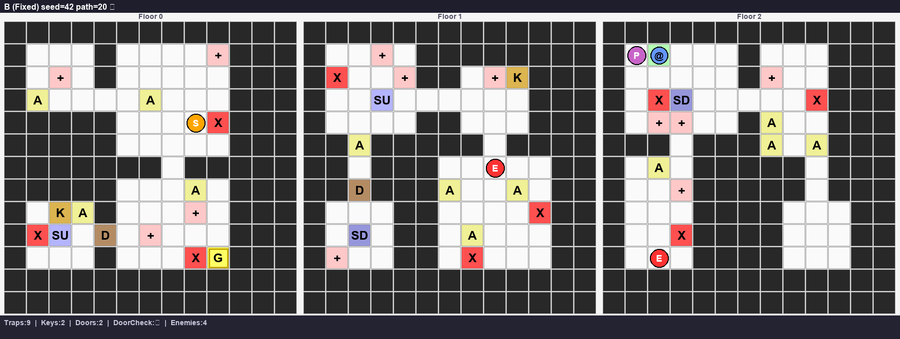


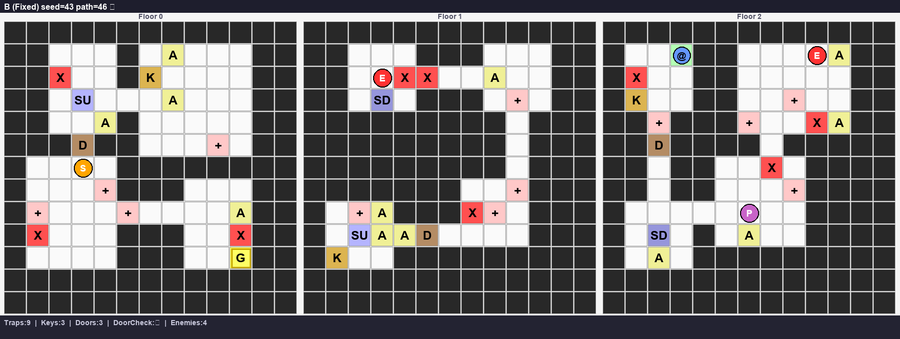


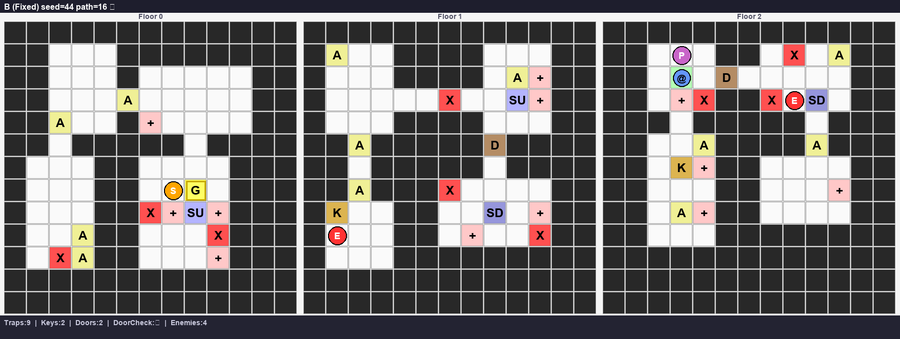


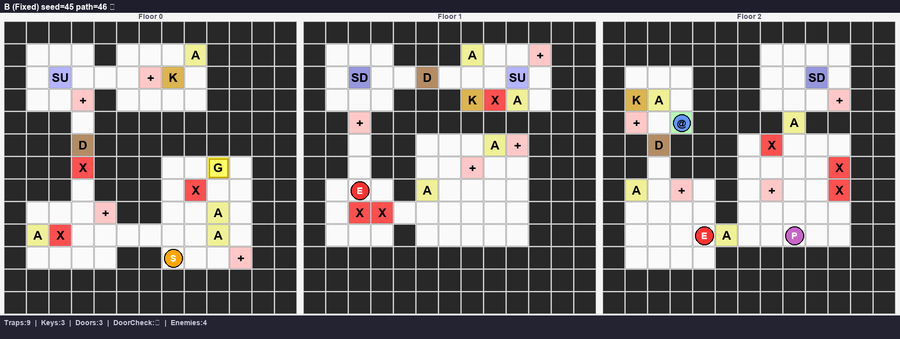

In [13]:
for seed in [r["seed"] for r in results_b if r["reachable"]][:4]:
    r = next(x for x in results_b if x["seed"]==seed)
    md = gen_b.generate(TARGET_CFG, seed=seed)
    if md is None: continue
    st = "✓" if r["door_ok"] else f"✗ {r['n_doors']}D/{r['n_keys']}K"
    img = render_floors(md["floors"], md["enemies"], md["start"], md["goal"],
                         f"B (Fixed) seed={seed} path={r['path']} {st}")
    show_img(img)


## C. Cellular Automata

Sinh map hữu cơ bằng CA:
1. Random fill ~45% floor
2. CA smoothing 5 iterations (rule: >=5 wall neighbors → wall)
3. Keep largest connected region
4. Place items trên region đó
5. Tìm chokepoint cho doors


In [14]:
class CAGenerator:
    def __init__(self, rng): self.rng = rng
    def _ca_step(self, g):
        h,w=g.shape; n=g.copy()
        for y in range(1,h-1):
            for x in range(1,w-1):
                walls=sum(1 for dy in range(-1,2) for dx in range(-1,2)
                          if (dy!=0 or dx!=0) and (not(0<=y+dy<h and 0<=x+dx<w) or int(g[y+dy][x+dx])==int(Tile.WALL)))
                n[y][x]=Tile.WALL if walls>=5 else Tile.FLOOR
        return n
    def _largest_region(self, g):
        h,w=g.shape; vis=set(); best=[]
        for y in range(h):
            for x in range(w):
                if int(g[y][x])==int(Tile.FLOOR) and (x,y) not in vis:
                    reg=[]; q=deque([(x,y)]); vis.add((x,y))
                    while q:
                        cx,cy=q.popleft(); reg.append((cx,cy))
                        for dx,dy in [(0,1),(0,-1),(1,0),(-1,0)]:
                            nx,ny=cx+dx,cy+dy
                            if 0<=nx<w and 0<=ny<h and (nx,ny) not in vis and int(g[ny][nx])==int(Tile.FLOOR):
                                vis.add((nx,ny)); q.append((nx,ny))
                    if len(reg)>len(best): best=reg
        return best
    def _gen_floor(self, w, h, fill=0.45, iters=5):
        g=np.full((h,w),Tile.WALL,dtype=np.int32)
        for y in range(1,h-1):
            for x in range(1,w-1):
                if self.rng.random()<fill: g[y][x]=Tile.FLOOR
        for _ in range(iters): g=self._ca_step(g)
        reg=self._largest_region(g)
        clean=np.full((h,w),Tile.WALL,dtype=np.int32)
        for x,y in reg: clean[y][x]=Tile.FLOOR
        return clean, reg
    def _pick(self, reg, used):
        cs=[p for p in reg if p not in used]
        if cs: c=cs[self.rng.randint(0,len(cs))]; used.add(c); return c
        return reg[0] if reg else (1,1)
    def _farthest(self, g, sx, sy):
        h,w=g.shape; vis={(sx,sy)}; q=deque([(sx,sy,0)]); best=(sx,sy,0)
        while q:
            cx,cy,d=q.popleft()
            if d>best[2]: best=(cx,cy,d)
            for dx,dy in [(0,1),(0,-1),(1,0),(-1,0)]:
                nx,ny=cx+dx,cy+dy
                if 0<=nx<w and 0<=ny<h and (nx,ny) not in vis and int(g[ny][nx])!=int(Tile.WALL):
                    vis.add((nx,ny)); q.append((nx,ny,d+1))
        return best[0],best[1]
    def _find_choke(self, g, sx, sy, gx, gy, used):
        h,w=g.shape; bl={int(Tile.WALL),int(Tile.DOOR)}
        parent={(sx,sy):None}; q=deque([(sx,sy)])
        while q:
            cx,cy=q.popleft()
            if cx==gx and cy==gy: break
            for dx,dy in [(0,1),(0,-1),(1,0),(-1,0)]:
                nx,ny=cx+dx,cy+dy
                if 0<=nx<w and 0<=ny<h and (nx,ny) not in parent and int(g[ny][nx]) not in bl:
                    parent[(nx,ny)]=(cx,cy); q.append((nx,ny))
        if (gx,gy) not in parent: return None
        path=[]; cur=(gx,gy)
        while cur: path.append(cur); cur=parent[cur]
        path.reverse()
        for cx,cy in path[1:-1]:
            if (cx,cy) in used: continue
            old=int(g[cy][cx]); g[cy][cx]=int(Tile.WALL)
            vis={(sx,sy)}; q2=deque([(sx,sy)]); found=False
            while q2:
                px,py=q2.popleft()
                if px==gx and py==gy: found=True; break
                for ddx,ddy in [(0,1),(0,-1),(1,0),(-1,0)]:
                    nx2,ny2=px+ddx,py+ddy
                    if 0<=nx2<w and 0<=ny2<h and (nx2,ny2) not in vis and int(g[ny2][nx2]) not in bl:
                        vis.add((nx2,ny2)); q2.append((nx2,ny2))
            g[cy][cx]=old
            if not found: return (cx,cy)
        return None
    def generate(self, config, seed=42, max_retries=20):
        for a in range(max_retries):
            self.rng=np.random.RandomState(seed+a*1000)
            r=self._gen_once(config)
            if r is not None:
                nk=sum(int(np.sum(f==int(Tile.KEY))) for f in r["floors"])
                nd=sum(int(np.sum(f==int(Tile.DOOR))) for f in r["floors"])
                pg=ProceduralMapGenerator(seed+a*1000)
                d=pg._bfs_multi(r["floors"],r["start"],r["goal"])
                if nk==nd and d>0: return r
        return self._gen_once(config)
    def _gen_once(self, config):
        nf=config.get("n_floors",1); w=config.get("width",12); h=config.get("height",12)
        all_f,all_reg=[],[]
        for _ in range(nf):
            g,reg=self._gen_floor(w,h)
            if len(reg)<(w*h)*0.15: return None
            all_f.append(g); all_reg.append(reg)
        used=set()
        for fi in range(nf-1):
            shared=set(all_reg[fi])&set(all_reg[fi+1])
            if shared: pos=list(shared)[self.rng.randint(0,len(shared))]
            else:
                pos=all_reg[fi][self.rng.randint(0,len(all_reg[fi]))]
                if int(all_f[fi+1][pos[1]][pos[0]])==int(Tile.WALL):
                    all_f[fi+1][pos[1]][pos[0]]=Tile.FLOOR; all_reg[fi+1].append(pos)
            all_f[fi][pos[1]][pos[0]]=Tile.STAIR_UP; all_f[fi+1][pos[1]][pos[0]]=Tile.STAIR_DOWN
            used.add(pos)
        sf=config.get("start_floor",nf-1); gf=config.get("goal_floor",0)
        sp=self._pick(all_reg[sf],used)
        gp=self._farthest(all_f[gf],sp[0],sp[1]); used.add(gp)
        all_f[sf][sp[1]][sp[0]]=Tile.START; all_f[gf][gp[1]][gp[0]]=Tile.GOAL
        start=(sp[0],sp[1],sf); goal=(gp[0],gp[1],gf)
        for fi in range(nf):
            g=all_f[fi]; reg=all_reg[fi]
            for _ in range(config.get("n_traps",0)): t=self._pick(reg,used); g[t[1]][t[0]]=Tile.TRAP
            for _ in range(config.get("n_health",0)): t=self._pick(reg,used); g[t[1]][t[0]]=Tile.HEALTH_PACK
            for _ in range(config.get("n_ammo",0)): t=self._pick(reg,used); g[t[1]][t[0]]=Tile.AMMO_PACK
        for lock in config.get("locks",[]):
            kfi=lock.get("k",0); dfi=lock.get("d",0)
            g=all_f[dfi]
            if dfi==sf: ex,ey=sp
            else:
                sp2=None
                for yy in range(h):
                    for xx in range(w):
                        look=int(Tile.STAIR_UP) if sf>dfi else int(Tile.STAIR_DOWN)
                        if int(g[yy][xx])==look: sp2=(xx,yy); break
                    if sp2: break
                if sp2 is None: continue
                ex,ey=sp2
            if dfi==gf: gx_,gy_=gp
            else:
                sp2=None
                for yy in range(h):
                    for xx in range(w):
                        look=int(Tile.STAIR_UP) if gf>dfi else int(Tile.STAIR_DOWN)
                        if int(g[yy][xx])==look: sp2=(xx,yy); break
                    if sp2: break
                if sp2 is None: continue
                gx_,gy_=sp2
            choke=self._find_choke(g,ex,ey,gx_,gy_,used)
            if choke:
                cx,cy=choke; g[cy][cx]=Tile.DOOR; used.add(choke)
                kt=self._pick(all_reg[kfi],used); all_f[kfi][kt[1]][kt[0]]=Tile.KEY
        enemies=[]
        for ec in config.get("enemies",[]):
            ef=ec.get("floor",0); pos=self._pick(all_reg[ef],used)
            enemies.append({"type":ec["type"],"floor":ef,"x":pos[0],"y":pos[1]})
        return {"floors":all_f,"rooms":[],"start":start,"goal":goal,
                "enemies":enemies,"n_floors":nf,"width":w,"height":h}

print("CAGenerator ready.")


CAGenerator ready.


In [15]:
print("=" * 70)
print("  Algorithm C: Cellular Automata")
print("=" * 70)

results_c = []
gen_c = CAGenerator(np.random.RandomState(42))
for seed in SEEDS:
    md = gen_c.generate(TARGET_CFG, seed=seed)
    if md is None:
        results_c.append({"seed":seed,"path":-1,"open_pct":0,"n_keys":0,"n_doors":0,"n_traps":0,"door_ok":False,"reachable":False})
        continue
    st = quick_stats(md["floors"], md["start"], md["goal"])
    pg = ProceduralMapGenerator(seed)
    dist = pg._bfs_multi(md["floors"], md["start"], md["goal"])
    results_c.append({"seed":seed,"path":dist,"open_pct":st["open_pct"],
                       "n_keys":st["n_keys"],"n_doors":st["n_doors"],"n_traps":st["n_traps"],
                       "door_ok":st["door_ok"],"reachable":dist>0})

n=len(results_c); dok=sum(1 for r in results_c if r["door_ok"])
rch=sum(1 for r in results_c if r["reachable"])
paths=[r["path"] for r in results_c if r["path"]>0]
print(f"\n  Reachable:    {rch}/{n} ({rch/n*100:.0f}%)")
print(f"  Door correct: {dok}/{n} ({dok/n*100:.0f}%)")
if paths: print(f"  Path range:   {min(paths)}-{max(paths)} (mean={np.mean(paths):.1f})")
else: print("  Path range:   N/A")


  Algorithm C: Cellular Automata

  Reachable:    30/30 (100%)
  Door correct: 30/30 (100%)
  Path range:   9-28 (mean=17.4)



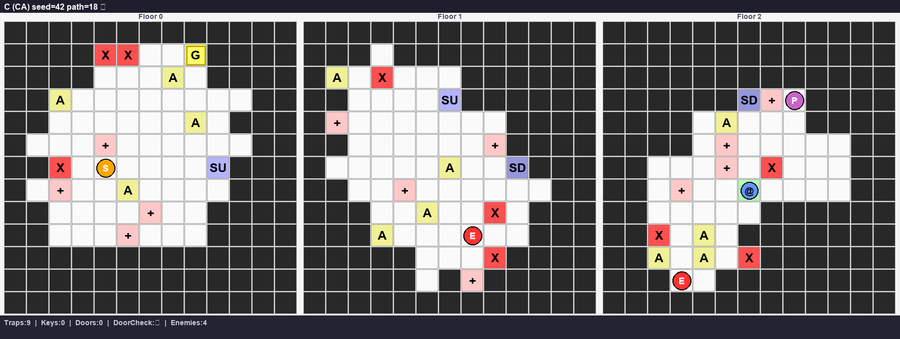


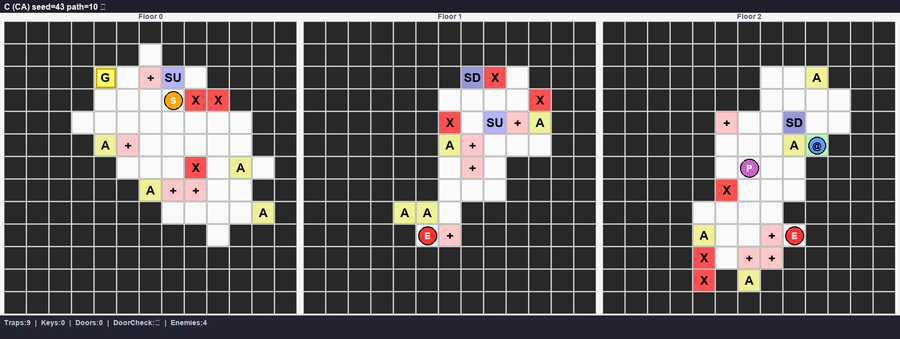


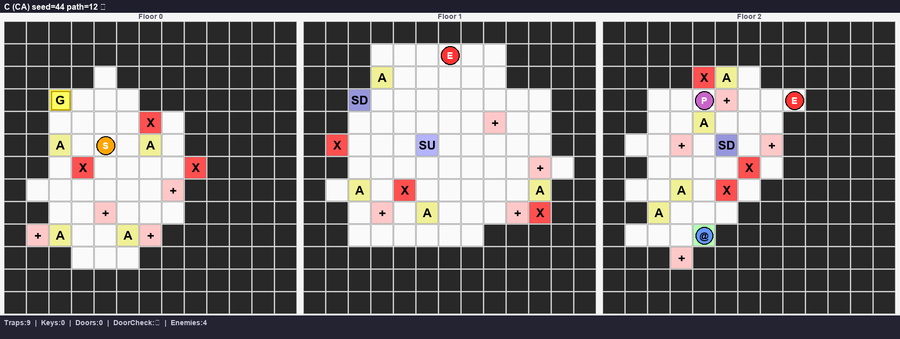


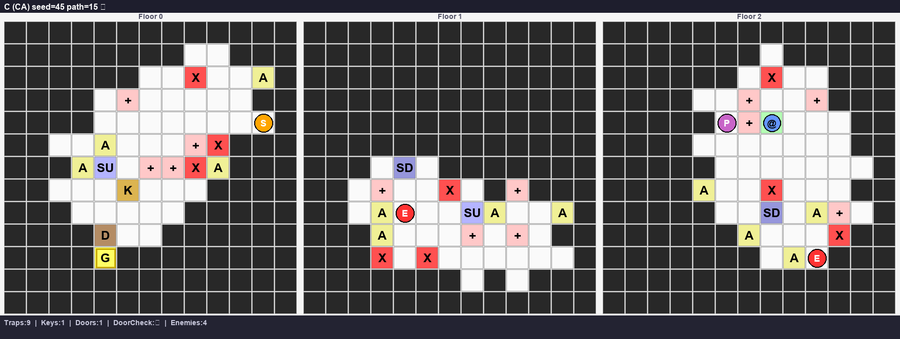

In [16]:
for seed in [r["seed"] for r in results_c if r["reachable"]][:4]:
    r = next(x for x in results_c if x["seed"]==seed)
    md = gen_c.generate(TARGET_CFG, seed=seed)
    if md is None: continue
    st = "✓" if r["door_ok"] else f"✗ {r['n_doors']}D/{r['n_keys']}K"
    img = render_floors(md["floors"], md["enemies"], md["start"], md["goal"],
                         f"C (CA) seed={seed} path={r['path']} {st}")
    show_img(img)


## So sánh tổng hợp

| Tiêu chí | Ý nghĩa |
|----------|---------|
| Reachable | Goal luôn tới được (100% = bắt buộc) |
| Door OK | Số door tiles == key tiles (100% = bắt buộc) |
| Path | Range rộng = đa dạng difficulty |
| Open% | 28-38% lý tưởng cho gameplay |


In [17]:
def summarize(name, results):
    n=len(results)
    rch=sum(1 for r in results if r["reachable"])
    dok=sum(1 for r in results if r["door_ok"])
    ps=[r["path"] for r in results if r["path"]>0]
    ops=[r["open_pct"] for r in results if r["open_pct"]>0]
    return {"name":name,
            "reachable":f"{rch}/{n} ({rch/n*100:.0f}%)",
            "door_ok":f"{dok}/{n} ({dok/n*100:.0f}%)",
            "path":f"{min(ps)}-{max(ps)} (μ={np.mean(ps):.0f})" if ps else "N/A",
            "open":f"{min(ops):.0f}-{max(ops):.0f}%" if ops else "N/A"}

rows = [summarize("A: BSP Baseline", results_a),
        summarize("B: BSP Fixed Lock", results_b),
        summarize("C: Cellular Automata", results_c)]

print(f"{'Algorithm':<22} {'Reachable':<16} {'Door OK':<16} {'Path Range':<22} {'Open%':<12}")
print("─" * 88)
for r in rows:
    print(f"{r['name']:<22} {r['reachable']:<16} {r['door_ok']:<16} {r['path']:<22} {r['open']:<12}")

print("\n" + "=" * 88)
print("Thuật nào có Reachable=100% VÀ Door OK=100% → ổn định nhất cho training.")
print("Xem hình ảnh mẫu ở trên để so sánh chất lượng layout.")


Algorithm              Reachable        Door OK          Path Range             Open%       
────────────────────────────────────────────────────────────────────────────────────────
A: BSP Baseline        30/30 (100%)     25/30 (83%)      13-46 (μ=26)           28-35%      
B: BSP Fixed Lock      30/30 (100%)     30/30 (100%)     12-46 (μ=26)           31-41%      
C: Cellular Automata   30/30 (100%)     30/30 (100%)     9-28 (μ=17)            23-45%      

Thuật nào có Reachable=100% VÀ Door OK=100% → ổn định nhất cho training.
Xem hình ảnh mẫu ở trên để so sánh chất lượng layout.
